In [ ]:
#data loading and cleaning

#import libraries
!pip install pandas
!pip install numpy
!pip install  matplotlib
!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine,text
import datetime

In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

In [3]:
df = pd.read_csv('OnlineRetail.csv', encoding = 'latin1')

In [4]:
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (541909, 8)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
column_meanings = {
    'InvoiceNo': 'Unique invoice number. If starts with C, it means cancellation',
    'StockCode': 'Product code',
    'Description': 'Product name',
    'Quantity': 'Number of items purchased',
    'InvoiceDate': 'Date and time of transaction',
    'UnitPrice': 'Price per unit',
    'CustomerID': 'Unique customer identifier',
    'Country': 'Customer country'
}

for col, meaning in column_meanings.items():
    print(f"{col}: {meaning}")

InvoiceNo: Unique invoice number. If starts with C, it means cancellation
StockCode: Product code
Description: Product name
Quantity: Number of items purchased
InvoiceDate: Date and time of transaction
UnitPrice: Price per unit
CustomerID: Unique customer identifier
Country: Customer country


In [9]:
#check cancelations
cancellations = df[df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"Number of cancellations : {len(cancellations)}")
print(f"Percentage : {(len(cancellations)/len(df))*100:.2f}%")

Number of cancellations : 9288
Percentage : 1.71%


In [10]:
#data cleaning


In [11]:
df_clean = df.copy()

In [12]:
#check missing values
print("Missing values before cleaning : ")
df_clean.isnull().sum()

Missing values before cleaning : 


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
#remove rows with missng customerid
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f"Rows after removing missing CustomerID: {len(df_clean)}")

Rows after removing missing CustomerID: 406829


In [15]:
#check discription missing
#fill missing description with 'unknown'

df_clean[df_clean['Description'].isnull()]
df_clean['Description'] = df_clean['Description'].fillna('Unknown')

In [16]:
#check quantity
print(f"Negative quantities: {(df_clean['Quantity'] < 0).sum()}")
print(f"Zero quantities: {(df_clean['Quantity'] == 0).sum()}")

Negative quantities: 8905
Zero quantities: 0


In [18]:
#keep only postive quantities

df_clean = df_clean[df_clean['Quantity'] > 0]
print(f"Rows after removing negative/zero quantity : {len(df_clean)}")

Rows after removing negative/zero quantity : 397924


In [19]:
#check unitprice
print(f"Zero or negative prices: {(df_clean['UnitPrice'] <= 0).sum()}")
df_clean = df_clean[df_clean['UnitPrice'] > 0]

Zero or negative prices: 40


In [21]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [24]:
#extract date features

df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.day_name()


In [25]:
#create total price column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [26]:
#check for outliers in TotalPrice

print("TotalPrice statistics: ")
print(df_clean['TotalPrice'].describe())

TotalPrice statistics: 
count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64


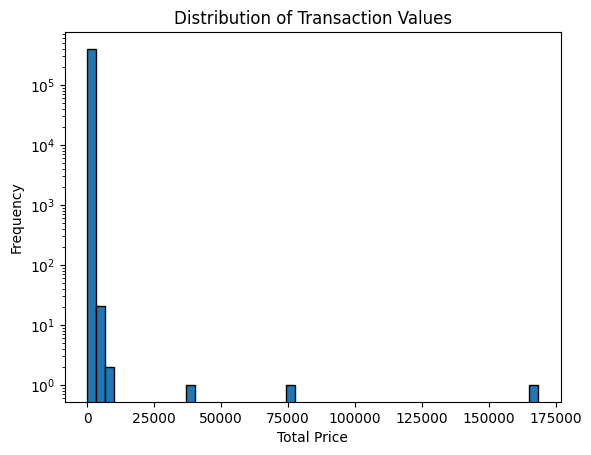

In [27]:
#plot

plt.figure()
plt.hist(df_clean['TotalPrice'], bins=50, edgecolor='black')
plt.title('Distribution of Transaction Values')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

In [29]:
#remove outliers

threshold = df_clean['TotalPrice'].quantile(0.999)
df_clean = df_clean[df_clean['TotalPrice'] < threshold]
print(f"Rows after removing extreme outliers: {len(df_clean)}")

Rows after removing extreme outliers: 397484


In [30]:
#final check

print(f"Final dataset shape: {df_clean.shape}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Unique customers : {df_clean['CustomerID'].nunique()}")
print(f"Uniques products: {df_clean['StockCode'].nunique()}")
print(f"Countries : {df_clean['Country'].nunique()}")

Final dataset shape: (397484, 14)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers : 4332
Uniques products: 3663
Countries : 37


In [31]:
df_clean.to_csv('online_retail_cleaned.csv', index=False)
print("Cleaned data saved to CSV")

Cleaned data saved to CSV


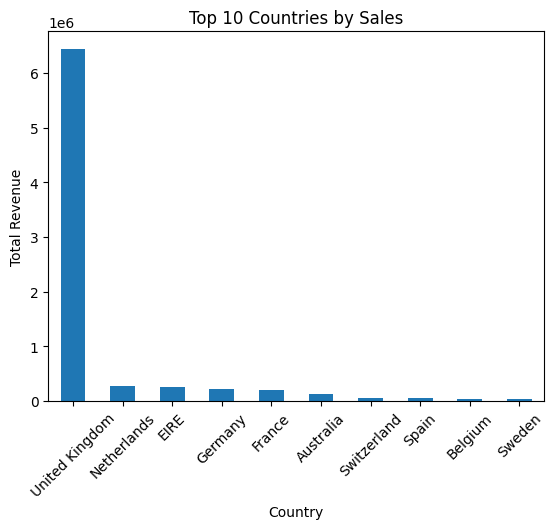

In [34]:
#visualizations

#top 10 countries by sales
country_sales = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure()
country_sales.plot(kind='bar')
plt.title('Top 10 Countries by Sales')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

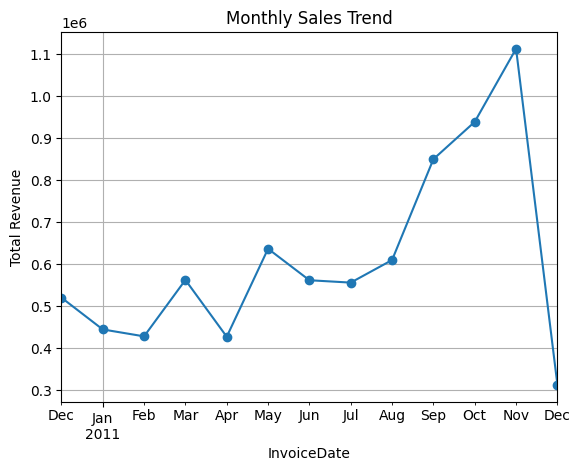

In [36]:
#monthly sales trend
monthly_sales = df_clean.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()
plt.figure()
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()